# ENTSO-E Yearly Price Pipeline

This notebook builds quarter-hourly energy price time series in `EUR/kWh` and saves them to Parquet.

- `2025` is built from `GUI_ENERGY_PRICES_202412312300-202512312300 (1).xlsx`
- `2026` starts from `GUI_ENERGY_PRICES_202512312300-202612312300.csv` and any missing quarter-hours are filled with a seasonal forecast profile
- `2027` is forecast from the available historical patterns in 2025 and 2026

All output series use a clean 15-minute grid starting at January 1st 00:00 for the target year.

In [1]:
# Optional: install notebook dependencies
%pip -q install pandas openpyxl pyarrow matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import importlib
import entsoe_price_utils
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

importlib.reload(entsoe_price_utils)

from entsoe_price_utils import (
    build_summary_table,
    build_partial_year_timeseries,
    build_year_timeseries,
    fill_missing_with_seasonal_profile,
    forecast_year_from_history,
    load_entsoe_csv_prices,
    load_entsoe_excel_prices,
    plot_year_subplots,
    read_legacy_year_parquet,
    write_legacy_year_parquet,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.6f}".format

In [3]:
base_dir = Path.cwd()

excel_2025_path = base_dir / "GUI_ENERGY_PRICES_202412312300-202512312300 (1).xlsx"
csv_2026_path = base_dir / "GUI_ENERGY_PRICES_202512312300-202612312300.csv"
parquet_dir = base_dir / "parquet_exports"

output_paths = {
    2025: parquet_dir / "entsoe_prices_2025.parquet",
    2026: parquet_dir / "entsoe_prices_2026.parquet",
    2027: parquet_dir / "entsoe_prices_2027.parquet",
}

output_paths

{2025: PosixPath('/Users/adriaan.smetsers/Documents/GitHub/wb4y-webscraper/Entsoe/parquet_exports/new_entsoe_prices_2025.parquet'),
 2026: PosixPath('/Users/adriaan.smetsers/Documents/GitHub/wb4y-webscraper/Entsoe/parquet_exports/new_entsoe_prices_2026.parquet'),
 2027: PosixPath('/Users/adriaan.smetsers/Documents/GitHub/wb4y-webscraper/Entsoe/parquet_exports/new_entsoe_prices_2027.parquet')}

In [4]:
forecast_config = {
    "random_seed_2026": 17,
    "random_seed_2027": 29,
    "noise_scale_2026": 0.55,
    "noise_scale_2027": 0.80,
    "smooth_window": 10,
}

forecast_config

{'random_seed_2026': 17,
 'random_seed_2027': 29,
 'noise_scale_2026': 0.55,
 'noise_scale_2027': 0.8,
 'smooth_window': 10}

In [5]:
raw_2025 = load_entsoe_excel_prices(excel_2025_path)
raw_2026 = load_entsoe_csv_prices(csv_2026_path)

year_2025 = build_year_timeseries(raw_2025, 2025)
year_2026_partial = build_partial_year_timeseries(raw_2026, 2026, source_year=2026)
year_2026 = fill_missing_with_seasonal_profile(
    year_2026_partial,
    [year_2025, year_2026_partial],
    add_randomness=True,
    random_seed=forecast_config["random_seed_2026"],
    noise_scale=forecast_config["noise_scale_2026"],
    smooth_window=forecast_config["smooth_window"],
)
year_2026["source_year"] = 2026
year_2027 = forecast_year_from_history(
    [year_2025, year_2026],
    2027,
    source_year=2026,
    add_randomness=True,
    random_seed=forecast_config["random_seed_2027"],
    noise_scale=forecast_config["noise_scale_2027"],
    smooth_window=forecast_config["smooth_window"],
)

built_frames = {
    2025: year_2025,
    2026: year_2026,
    2027: year_2027,
}

build_summary_table(built_frames)

,year,rows,missing,start,end,min_eur_kwh,max_eur_kwh,mean_eur_kwh
0,2025,35040,0,2025-01-01,2025-12-31 23:45:00,-0.350000,0.523470,0.087216
1,2026,35040,0,2026-01-01,2026-12-31 23:45:00,-0.103088,0.482894,0.084464
2,2027,35040,0,2027-01-01,2027-12-31 23:45:00,-0.133446,0.304531,0.085671


In [6]:
comparison_2026 = pd.DataFrame(
    {
        "version": ["raw-aligned-2026", "filled-2026"],
        "rows": [len(year_2026_partial), len(year_2026)],
        "missing": [year_2026_partial["price_eur_kwh"].isna().sum(), year_2026["price_eur_kwh"].isna().sum()],
        "mean_eur_kwh": [year_2026_partial["price_eur_kwh"].mean(), year_2026["price_eur_kwh"].mean()],
    }
)

comparison_2026

,version,rows,missing,mean_eur_kwh
0,raw-aligned-2026,35040,26500,0.099804
1,filled-2026,35040,0,0.084464


In [7]:
for year, frame in built_frames.items():
    write_legacy_year_parquet(frame, output_paths[year])

sorted(str(path) for path in output_paths.values())

['/Users/adriaan.smetsers/Documents/GitHub/wb4y-webscraper/Entsoe/parquet_exports/new_entsoe_prices_2025.parquet',
 '/Users/adriaan.smetsers/Documents/GitHub/wb4y-webscraper/Entsoe/parquet_exports/new_entsoe_prices_2026.parquet',
 '/Users/adriaan.smetsers/Documents/GitHub/wb4y-webscraper/Entsoe/parquet_exports/new_entsoe_prices_2027.parquet']

In [ ]:
legacy_2026_preview_path = output_paths[2026]
if not legacy_2026_preview_path.exists():
    if "built_frames" not in globals():
        raise FileNotFoundError(
            f"{legacy_2026_preview_path} does not exist yet. Run the build/write cells first."
        )
    write_legacy_year_parquet(built_frames[2026], legacy_2026_preview_path)

legacy_2026_preview = pd.read_parquet(legacy_2026_preview_path)
legacy_2026_preview.head()

In [8]:
reloaded_frames = {
    year: read_legacy_year_parquet(path, year=year)
    for year, path in output_paths.items()
}

build_summary_table(reloaded_frames)

,year,rows,missing,start,end,min_eur_kwh,max_eur_kwh,mean_eur_kwh
0,2025,35040,0,2025-01-01,2025-12-31 23:45:00,-0.350000,0.523470,0.087216
1,2026,35040,0,2026-01-01,2026-12-31 23:45:00,-0.103088,0.482894,0.084464
2,2027,35040,0,2027-01-01,2027-12-31 23:45:00,-0.133446,0.304531,0.085671


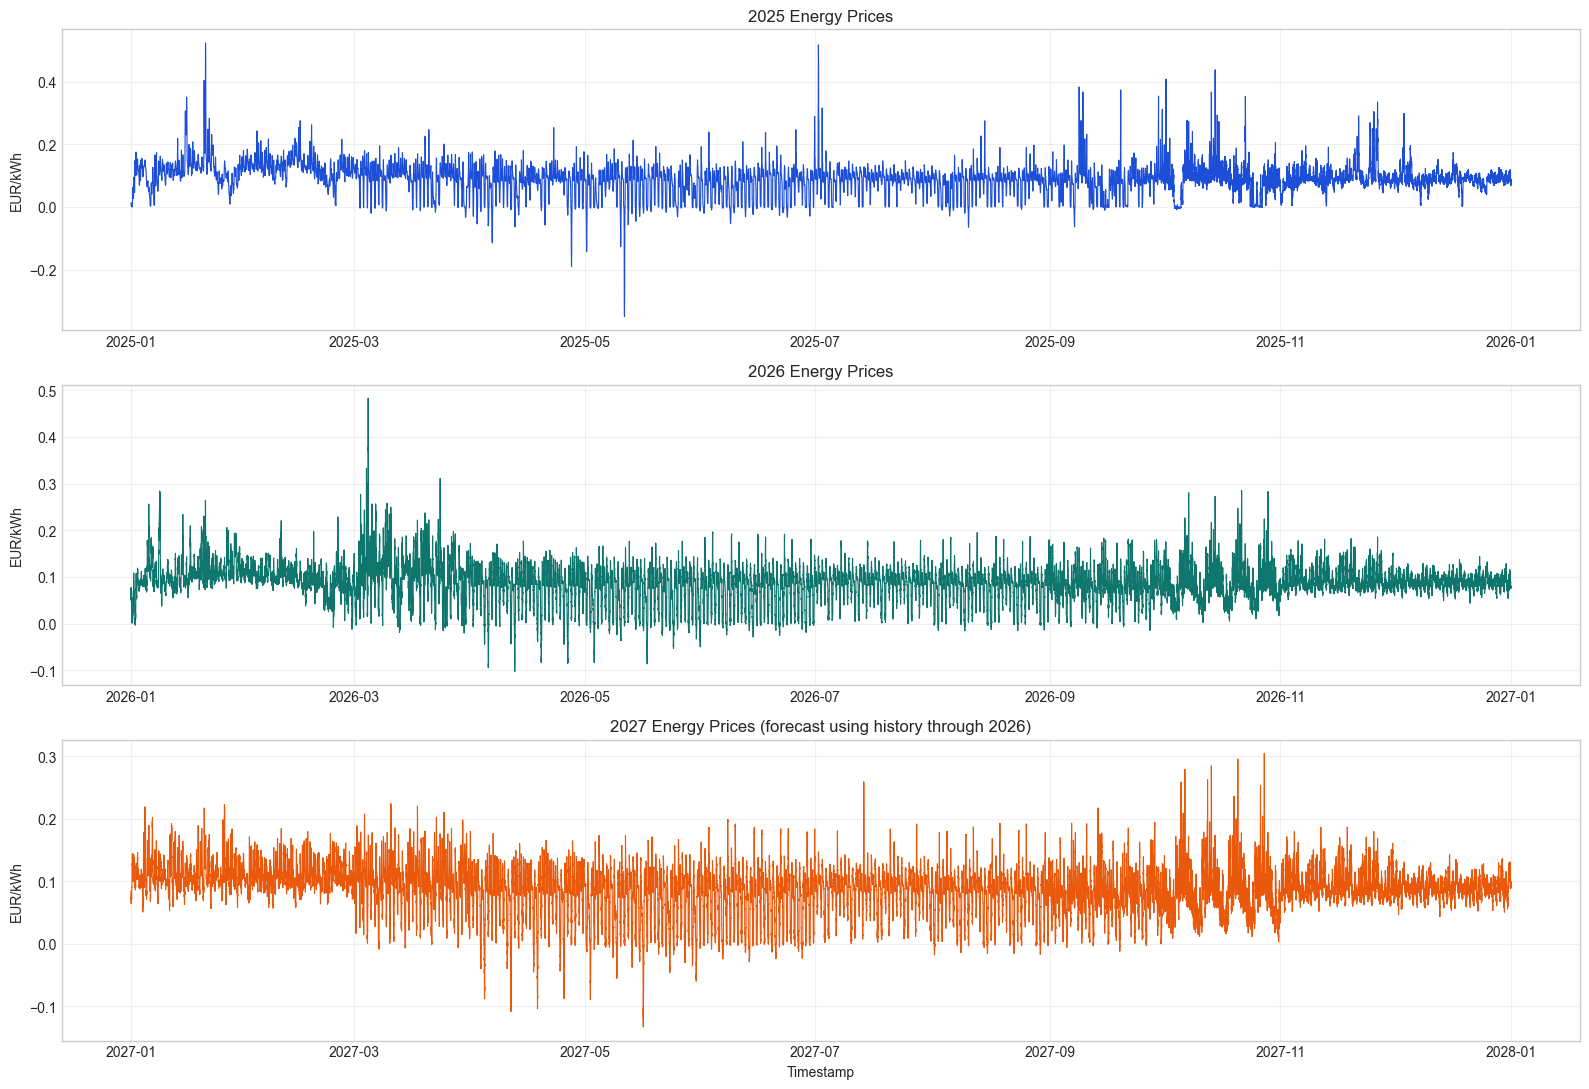

In [9]:
fig, axes = plot_year_subplots(reloaded_frames)
plt.show()